### Veriyi Yükleme

Veri manipülasyonu için pandas kütüphanesini pd, NumPy kütüphanesi np alias'ı ile import ediyoruz.

In [1]:
import pandas as pd
import numpy as np

### Veriyi CSV formatından DataFrame formatına dönüştürme

In [2]:
df=pd.read_csv("sales_data.csv")

### Veri setinin boyutunu bulma
EDA (Exploratory Data Analysis) sürecinde bilmemiz verinin boyutunu bilmemiz gerekir.

In [3]:
print("Veri setinin boyutu:\n")
print(df.shape)

Veri setinin boyutu:

(500, 7)


### Veri setinde boş hücre kontrolü
Veri setindeki boş değerlerin tespit edilmesi, boş değerlerin olduğu sütunları doldurmak veya silmek zorundayız. 

In [4]:
print("Veri setinin sütunlarında boş hücre var mı ? \n")
print(df.isna().sum())

Veri setinin sütunlarında boş hücre var mı ? 

order_id       0
date           0
region        76
product       45
quantity      31
unit_price    28
sales_rep      0
dtype: int64


### Veri setindeki sayısal sütunlara matematiksel bakış
Veri setindeki sayısal sütunlara matematiksel (mod,medyan,min,max) gibi işlemler uygulayarak outlier tespiti yapıyoruz.

In [5]:
print("Veri setinin sayısal sütunlarından çıkarılan matematiksel sonuçlar ne? \n")
print(df.describe())

Veri setinin sayısal sütunlarından çıkarılan matematiksel sonuçlar ne? 

         order_id    quantity   unit_price
count  500.000000  469.000000   472.000000
mean   250.500000    1.373134  1297.872881
std    144.481833    1.137644  1105.925688
min      1.000000   -1.000000  -999.000000
25%    125.750000    1.000000   499.000000
50%    250.500000    1.000000   999.000000
75%    375.250000    2.000000  1499.000000
max    500.000000    3.000000  2999.000000


### Veri setine genel bakış
Veri setinin sütunları, bilgisayarda kapladığı yer de EDA sürecinde kontrol etmemiz gereken değişkenlerden biridir.

In [6]:
print("Veri seti hakkında genel bilgi: \n")
print(df.info())

Veri seti hakkında genel bilgi: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    500 non-null    int64  
 1   date        500 non-null    object 
 2   region      424 non-null    object 
 3   product     455 non-null    object 
 4   quantity    469 non-null    float64
 5   unit_price  472 non-null    float64
 6   sales_rep   500 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 27.5+ KB
None


### Veri setinin İlk 5 Satırı
Veri setinin ilk 5 satırına bakarak veri setine dair kafamızda genel bir görüntü canlandırıyoruz.

In [7]:
print("Veri setinin ilk 5 satırı: \n")
print(df.head())

Veri setinin ilk 5 satırı: 

   order_id        date    region  product  quantity  unit_price sales_rep
0         1  2023-01-01    Ankara   Tablet       1.0      2999.0     Fatma
1         2  2023-01-02     Bursa    Phone       2.0      2999.0    Mehmet
2         3  2023-01-03     Izmir    Phone      -1.0       999.0     Fatma
3         4  2023-01-04     Izmir  Monitor       3.0      1499.0      Ayşe
4         5  2023-01-05  Istanbul   Tablet       3.0      1499.0      Ayşe


### Veri setindeki boş değerlerin doldurulması
Veri setinde region ve product sütunları kategorik olduğundan bu sütunlardaki boş değerler "Bilinmiyor", sayısal sütunlardaki boş değerler ise bu sütunlarda outlier değerler bulunduğundan (outlier değer olduğunda ortalama uç değerlerden etkilenir) bu hücreleri ilgili sütunun medyan değerleri ile doldurduk. 

In [8]:
df["region"]=df["region"].fillna(value="unknown")
df["product"]=df["product"].fillna(value="unknown")
quantity_median=df["quantity"].median()
unit_price_median=df["unit_price"].median()
df["quantity"]=df["quantity"].fillna(quantity_median)
df["unit_price"]=df["unit_price"].fillna(unit_price_median)

### Boş değerlerin doldurulup doldurulmadığını kontrol etmek
Bu kod yukarıdaki işlemin çalışıp çalışmadığını kontrol etmek amacıyla yazılmıştır.

In [9]:
df.isna().sum() 

order_id      0
date          0
region        0
product       0
quantity      0
unit_price    0
sales_rep     0
dtype: int64

### Veri setindeki yanlış verileri temizleme süreci
Mevcut veri setinde fiyat ve miktar sütunlarında negatif değerler olduğunu tespit ettik bu değerlerin yanlış veriler olmasından ötürü bu verilere ait satırları veri setinden siliyoruz.

In [10]:
# negatif quantity ve unit price değerleri yanlış veri olduğu için siliyoruz.
df=df[(df["quantity"]>0) & (df["unit_price"]>0)]
df=df.reset_index(drop=True)

### Toplam ücret sütununun türetilmesi
miktar * fiyat ile bir kişinin toplam yaptığı harcamayı buluyoruz. Bu bilgiyi gruplamada kullanacağız.

In [11]:
df["total_revenue"] = df["quantity"] * df["unit_price"]

### Ürünlere göre satış miktarlarının ve satış adetlerinin toplanması
Ürünlere göre gruplama, miktar ve toplam harcama üzerinden ürünlerin analiz edilmesi.

Ürün sütununda bilinmiyor değerine sahip satırların analizden kaldırılması

In [12]:
df_clean=df[df["product"] != "unknown"]

Ürünlerin toplam harcamalarına göre büyükten küçüğe sıralanması ve ilgili grafikte ürün adlarının x ekseninde gözükebilmesi için reset_index fonksiyonu
yardımıyla ürün adlarının bir sütun haline dönüştürülmesi

In [13]:
product_sales=df_clean.groupby("product")[["quantity","total_revenue"]].sum().sort_values(by="total_revenue",ascending=False).reset_index()

### Bölgelere göre satış miktarlarının ve satış adetlerinin toplanması
Bölge sütununda bilinmeyen bölge değerlerine sahip satırları analizden kaldırıyoruz.

In [14]:
df_clean1=df[df["region"] != "unknown"]

Bölgelerin toplam harcamalarına göre büyükten küçüğe sıralanması ve ilgili grafikte bölge adlarının x ekseninde gözükebilmesi için reset_index fonksiyonu
yardımıyla bölge adlarının bir sütun haline dönüştürülmesi

In [15]:
region_sales=df_clean1.groupby("region")[["quantity", "total_revenue"]].sum().sort_values(by="total_revenue",ascending=False).reset_index()

İnteraktif grafikler yapabilmek için plotly kütüphanesinden express modülünü px alias'ı ile import ediyoruz. Fonksiyonlara bu alias'ı kullanarak ulaşacağız.

In [16]:
import plotly.express as px

### Sonuçların analiz edilmesi
İlk grafik ürünlere göre toplam satışların görselleştirmesi iken, ikinci grafik bölgelere göre toplam satışların görselleştirilmesidir.

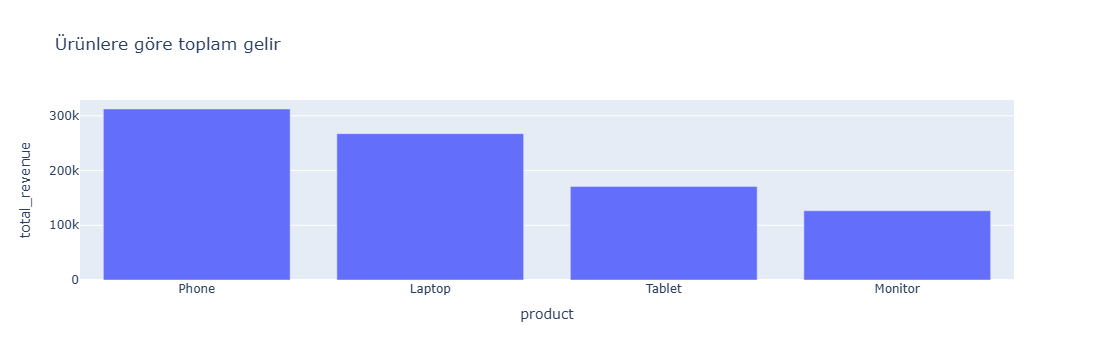

In [17]:
fig= px.bar(
    data_frame=product_sales,
    x="product",
    y="total_revenue",
    title="Ürünlere göre toplam gelir"
)
fig.show()

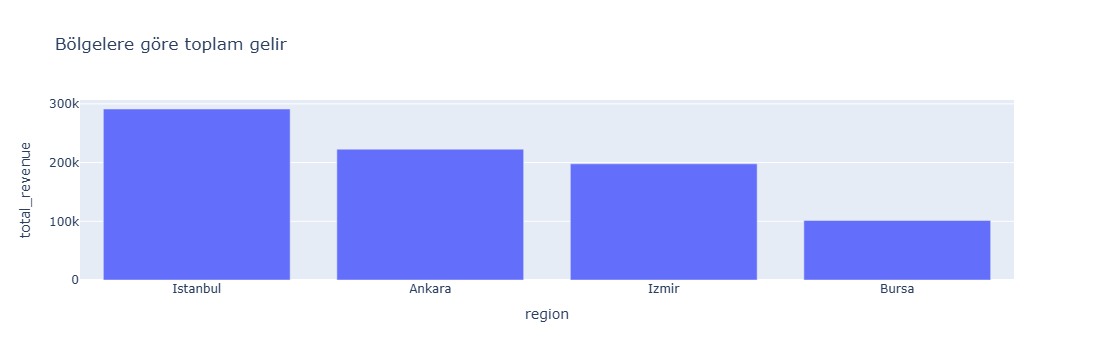

In [18]:
fig1= px.bar(
    data_frame=region_sales,
    x="region",
    y="total_revenue",
    title="Bölgelere göre toplam gelir"
)
fig1.show()

### SONUÇ
* Veri setine Dair Keşifsel Veri Analizi (EDA) yapıldı. Boş değer içeren sütunlar ilgili sütun sayısal ise medyan ile kategorik ise "unknown" ifadesiyle dolduruldu.
* Outlier olarak tespit edilen quantity ve unit_price sütunundaki değerler tespit edilerek veri setinden kaldırıldı.
* quantity * unit_price=total_revenue olacak şekilde yeni sütun türetildi.
* Bu türetilen yeni sütun üzerinden bölgeler ve ürünler gruplandırılarak toplam harcanan tutar ve toplam satış adetleri bulundu.
* **Bu gruplandırma analizinden çıkan sonuçlara göre:**
* En iyi performans gösteren ürün telefon ve en iyi performans gösteren bölge İstanbul.
* En kötü performans gösteren ürün monitör ve en kötü performans gösteren bölge Bursa.
* **Şirkete önerim:**
* İstanbulda stokların sürekli yenilenmesi ve özellikle telefon stoklarının sürekli yenilenmesi yönünde.
* Monitor ürünü çok az satıldığından dolayı satışları artırmak amacıyla indirim düzenlenebilir.
* Bursa özelinde ise insanların aldıkları ürünlere ücretsiz kargo hizmetleri sunularak insanları markaya ısındırma süreçleri olabilir.